# Extrapolation validation of GPQR models for H

This notebook visualizes extrapolation performance of models with and without physical priors.

Models with constant prior show inferior extrapolation performance.

In [ ]:
import sys
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))

try:
    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

## Load data

In [ ]:
gpr_ev = pd.read_csv("../_temp/extrapolation.GPR_H.csv").values
gpr_cm_ev = pd.read_csv("../_temp/extrapolation.GPR_H_ConstantMean.csv").values
cg_lmc_ev = pd.read_csv("../_temp/extrapolation.CgLmcMtgpqr_H.csv").values
cg_lmc_cm_ev = pd.read_csv(
    "../_temp/extrapolation.CgLmcMtgpqr_H_ConstantMean.csv"
).values
cg_independent_ev = pd.read_csv(
    "../_temp/extrapolation.CgIndependentMtgpqr_H.csv"
).values
cg_independent_cm_ev = pd.read_csv(
    "../_temp/extrapolation.CgIndependentMtgpqr_H_ConstantMean.csv"
).values

## Plot

In [ ]:
def sci_label(value: float, precision: int = 2) -> str:
    if value == 0:
        return f"{0:.{precision}f} × 10^0"
    exponent = math.floor(math.log10(abs(value)))
    mantissa = value / (10**exponent)
    return f"{mantissa:.{precision}f} × 10^{exponent}"

### Loss by epoch

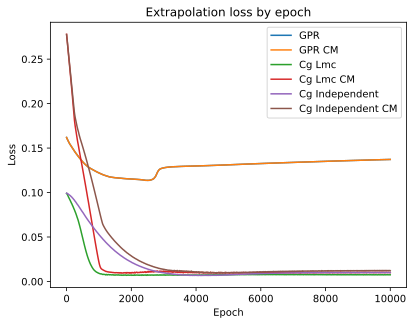

In [ ]:
plt.plot(gpr_ev.mean(axis=1), label="GPR")
plt.plot(gpr_cm_ev.mean(axis=1), label="GPR CM")
plt.plot(cg_lmc_ev.mean(axis=1), label="Cg Lmc")
plt.plot(cg_lmc_cm_ev.mean(axis=1), label="Cg Lmc CM")
plt.plot(cg_independent_ev.mean(axis=1), label="Cg Independent")
plt.plot(cg_independent_cm_ev.mean(axis=1), label="Cg Independent CM")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Extrapolation loss by epoch")
plt.legend()
plt.show()

### Minimum loss

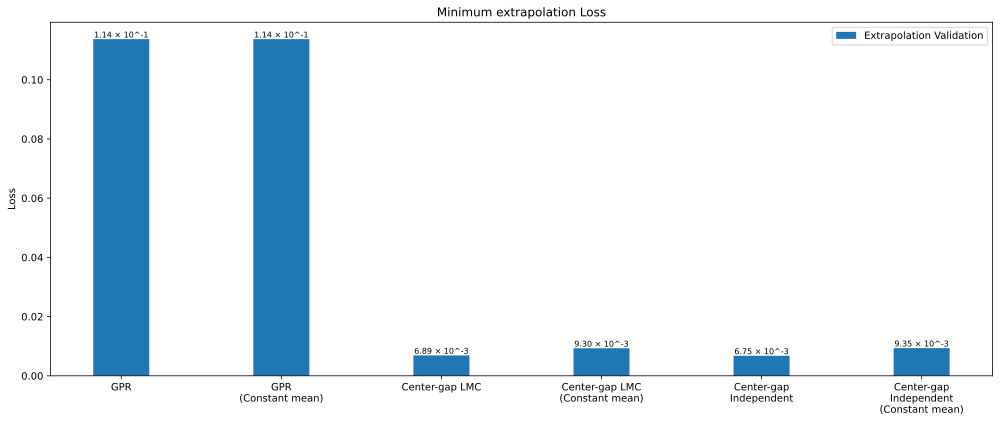

In [ ]:
names = [
    "GPR",
    "GPR\n(Constant mean)",
    "Center-gap LMC",
    "Center-gap LMC\n(Constant mean)",
    "Center-gap\nIndependent",
    "Center-gap\nIndependent\n(Constant mean)",
]
ev_losses = [
    gpr_ev.mean(axis=1).min(),
    gpr_cm_ev.mean(axis=1).min(),
    cg_lmc_ev.mean(axis=1).min(),
    cg_lmc_cm_ev.mean(axis=1).min(),
    cg_independent_ev.mean(axis=1).min(),
    cg_independent_cm_ev.mean(axis=1).min(),
]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars_ev = ax.bar(x, ev_losses, width, label="Extrapolation Validation")

for bar in list(bars_ev):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        sci_label(height),
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("Loss")
ax.set_title("Minimum extrapolation Loss")
ax.legend()
plt.tight_layout()
plt.show()